<a href="https://colab.research.google.com/github/viniciusarnom/estudo_dirigido/blob/main/C%C3%B3digo%20Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape da Matriz de Features: (22500000, 5)
Exemplo da 1ª linha [Label, I, Q, Mag, Espectro]:
[0.0000000e+00 0.0000000e+00 7.9348107e-04 7.9348107e-04 1.2474245e+01]


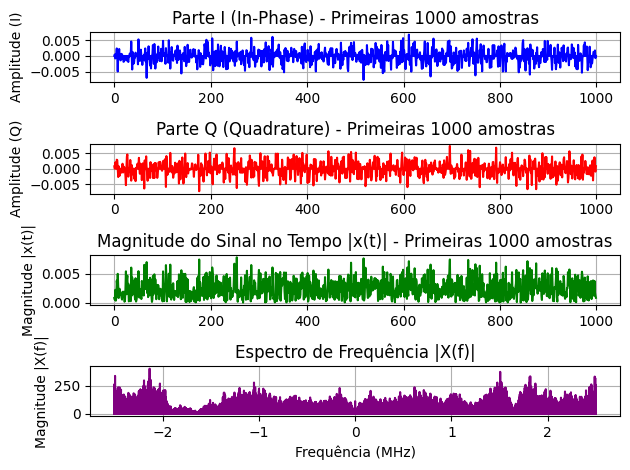

Ficheiro guardado com sucesso: features_WiFi_Day_1_bes_s1_saida.bin


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar os dados do arquivo bruto s1
arquivo_entrada = 'WiFi_Day_1_bes_slice_completo.bin'

# Lemos diretamente como complex64, pois este é o arquivo original
data = np.fromfile(arquivo_entrada, dtype=np.complex64)
x_t = data

# 2. Extrair as 5 Features solicitadas

# Feature 1: Label (Número 0 para todas as linhas)
feature_label = np.zeros(len(x_t), dtype=np.float32)

# Feature 2 e 3: Parte I (In-Phase) e Parte Q (Quadrature)
feature_I = np.real(x_t).astype(np.float32)
feature_Q = np.imag(x_t).astype(np.float32)

# Feature 4: Magnitude |x(t)|
feature_magnitude = np.abs(x_t).astype(np.float32)

# Feature 5: Espectro X(f) = F{x(t)}
X_f = np.fft.fft(x_t)
X_f_shifted = np.fft.fftshift(X_f)
feature_espectro = np.abs(X_f_shifted).astype(np.float32)

# =====================================================================
# ARMAZENAR TUDO EM UMA ÚNICA MATRIZ
# Formato resultante: [Label(0), I, Q, Magnitude Tempo, Magnitude Espectro]
# =====================================================================
matriz_features = np.column_stack((feature_label, feature_I, feature_Q, feature_magnitude, feature_espectro))

print(f"Shape da Matriz de Features: {matriz_features.shape}")
print(f"Exemplo da 1ª linha [Label, I, Q, Mag, Espectro]:\n{matriz_features[0]}")


# 3. Preparar o eixo de frequências (fs = 5 MHz)
fs = 5e6
freqs = np.fft.fftshift(np.fft.fftfreq(len(x_t), 1/fs))

# ================= Gráfico 1: Parte I =================
plt.subplot(4, 1, 1)
plt.plot(feature_I[:1000], color='blue')
plt.title('Parte I (In-Phase) - Primeiras 1000 amostras')
plt.ylabel('Amplitude (I)')
plt.grid(True)

# ================= Gráfico 2: Parte Q =================
plt.subplot(4, 1, 2)
plt.plot(feature_Q[:1000], color='red')
plt.title('Parte Q (Quadrature) - Primeiras 1000 amostras')
plt.ylabel('Amplitude (Q)')
plt.grid(True)

# ================= Gráfico 3: Magnitude =================
plt.subplot(4, 1, 3)
plt.plot(feature_magnitude[:1000], color='green')
plt.title('Magnitude do Sinal no Tempo |x(t)| - Primeiras 1000 amostras')
plt.ylabel('Magnitude |x(t)|')
plt.grid(True)

# ================= Gráfico 4: Espectro =================
plt.subplot(4, 1, 4)
plt.plot(freqs / 1e6, feature_espectro, color='purple')
plt.title('Espectro de Frequência |X(f)|')
plt.xlabel('Frequência (MHz)')
plt.ylabel('Magnitude |X(f)|')
plt.grid(True)

# Ajustar o layout e guardar a imagem
plt.tight_layout()
plt.savefig('todas_features_bes_s1.png')
plt.show()

# =========================================================
# GERAR O FICHEIRO DE SAÍDA .BIN
# =========================================================

nome_bin = 'features_WiFi_Day_1_bes_s1_saida.bin'

# O método tofile grava o array diretamente como bytes puros
matriz_features.tofile(nome_bin)

print(f"Ficheiro guardado com sucesso: {nome_bin}")